## MITSUI&CO Commodity Prediction - LSTM Model

## Armstrong LSTM Model:
    - Ranking loss (differntiable spearman)
    - PCA compression - reduces features to about 100 components
    - simpler LSTM - no bidirectional, no attention, and smaller hidden size to improve generalization
    - walk forward validation  - train on 0-1599, validate on 1600-1826
    - Cross sectional training - each batch contains all targets for a given data
    - competition metric is tracked while training

In [1]:
# %% ============================================================
# CELL 1: Imports & Configuration
# ===============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import gc
import time
from pathlib import Path
from scipy.stats import spearmanr
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
 
warnings.filterwarnings("ignore")
 
# ── Paths ─────────────────────────────────────────────────────
DATA_PATH = Path("data")
 
# ── Hyperparameters ───────────────────────────────────────────
SEQUENCE_LENGTH  = 20
HIDDEN_SIZE      = 32
NUM_LAYERS       = 1
DROPOUT          = 0.4
LEARNING_RATE    = 5e-4
WEIGHT_DECAY     = 1e-3
EPOCHS           = 100
BATCH_SIZE       = 64
PATIENCE         = 25
N_PCA            = 100
N_SEEDS          = 3
TRAIN_END        = 1750
VAL_END          = 1827
RANK_LOSS_ALPHA  = 0.0      # pure MSE

# Walk-forward splits
TRAIN_END        = 1600     # train on dates < 1600
VAL_END          = 1827     # validate on 1600-1826, test on 1827-1960
 
# Loss blending: alpha * ranking_loss + (1 - alpha) * mse_loss
RANK_LOSS_ALPHA  = 0.7      # weight towards ranking loss
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
# %% ============================================================
# CELL 2: Load Data
# ===============================================================
train        = pd.read_csv(DATA_PATH / "train.csv").sort_values("date_id").reset_index(drop=True)
train_labels = pd.read_csv(DATA_PATH / "train_labels.csv").sort_values("date_id").reset_index(drop=True)
test         = pd.read_csv(DATA_PATH / "test.csv").sort_values("date_id").reset_index(drop=True)
ground_truth = pd.read_csv(DATA_PATH / "test_ground_truth.csv").sort_values("date_id").reset_index(drop=True)
target_pairs = pd.read_csv(DATA_PATH / "target_pairs.csv")
 
if "is_scored" in test.columns:
    is_scored = test["is_scored"].copy()
    test = test.drop(columns=["is_scored"])
 
feature_cols = [c for c in train.columns if c != "date_id"]
target_cols  = [c for c in train_labels.columns if c != "date_id"]
 
lag_groups = {}
for lag in [1, 2, 3, 4]:
    lag_groups[lag] = target_pairs.loc[target_pairs["lag"] == lag, "target"].tolist()
 
print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Features: {len(feature_cols)}, Targets: {len(target_cols)}")
print(f"Train period: 0-{TRAIN_END-1}, Val period: {TRAIN_END}-{VAL_END-1}, Test: {VAL_END}-1960")

Train: (1961, 558), Test: (134, 558)
Features: 557, Targets: 424
Train period: 0-1599, Val period: 1600-1826, Test: 1827-1960


In [3]:
# %% ============================================================
# CELL 3: Feature Engineering (streamlined)
# ===============================================================
def get_pair_assets(pair_str):
    if " - " in pair_str:
        a, b = pair_str.split(" - ", 1)
        return a.strip(), b.strip()
    return pair_str.strip(), None


def engineer_features(df, target_pairs_df):
    """Build features: returns + pair spreads + rolling stats."""
    feat = pd.DataFrame({"date_id": df["date_id"].values})

    all_assets = set()
    for _, row in target_pairs_df.iterrows():
        a, b = get_pair_assets(row["pair"])
        all_assets.add(a)
        if b:
            all_assets.add(b)
    target_assets = sorted([c for c in all_assets if c in df.columns])

    # ── Returns at multiple horizons ──────────────────────────
    for col in target_assets:
        for h in [1, 2, 5, 10, 20]:
            feat[f"{col}_ret{h}"] = df[col].pct_change(h)

    # ── Rolling stats ─────────────────────────────────────────
    for col in target_assets:
        ret1 = df[col].pct_change(1)
        feat[f"{col}_vol5"]  = ret1.rolling(5).std()
        feat[f"{col}_vol20"] = ret1.rolling(20).std()
        feat[f"{col}_mom5"]  = ret1.rolling(5).mean()
        feat[f"{col}_mom20"] = ret1.rolling(20).mean()

    # ── Pair spread returns ───────────────────────────────────
    pairs_done = set()
    for _, row in target_pairs_df.iterrows():
        a, b = get_pair_assets(row["pair"])
        if b is None:
            continue
        key = f"{a}__{b}"
        if key in pairs_done or a not in df.columns or b not in df.columns:
            continue
        pairs_done.add(key)

        spread = df[a] - df[b]
        feat[f"{key}_sret1"] = spread.pct_change(1)
        feat[f"{key}_sret5"] = spread.pct_change(5)
        feat[f"{key}_relmom5"] = df[a].pct_change(5) - df[b].pct_change(5)

    feat = feat.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return feat


print("Engineering features...")
t0 = time.time()
train_feat = engineer_features(train, target_pairs)
test_feat  = engineer_features(test, target_pairs)
eng_cols = [c for c in train_feat.columns if c != "date_id"]
print(f"Done in {time.time()-t0:.1f}s — {len(eng_cols)} raw features")

Engineering features...
Done in 2.5s — 2064 raw features


In [4]:
# %% ============================================================
# CELL 4: PCA Compression + Scaling
# ===============================================================
scaler = RobustScaler()
train_mask = train_feat["date_id"] < TRAIN_END
 
# Fit scaler on training data only
scaler.fit(train_feat.loc[train_mask, eng_cols])
train_scaled = scaler.transform(train_feat[eng_cols]).astype(np.float32)
test_scaled  = scaler.transform(test_feat[eng_cols]).astype(np.float32)
 
# Clip outliers
train_scaled = np.clip(train_scaled, -5, 5)
test_scaled  = np.clip(test_scaled, -5, 5)
 
# PCA fit on training data
pca = PCA(n_components=N_PCA)
pca.fit(train_scaled[train_mask.values])
print(f"PCA({N_PCA}) explained variance: {pca.explained_variance_ratio_.sum():.4f}")
 
train_pca = pca.transform(train_scaled).astype(np.float32)
test_pca  = pca.transform(test_scaled).astype(np.float32)
 
train_label_arr = train_labels[target_cols].values.astype(np.float32)
 
print(f"Final feature shape — Train: {train_pca.shape}, Test: {test_pca.shape}")

PCA(100) explained variance: 0.9389
Final feature shape — Train: (1961, 100), Test: (134, 100)


In [5]:
# %% ============================================================
# CELL 5: Dataset (cross-sectional aware)
# ===============================================================
class CommodityDataset(Dataset):
    """Sliding-window dataset for LSTM."""
 
    def __init__(self, features, targets, seq_len):
        self.features = features
        self.targets  = targets
        self.seq_len  = seq_len
 
    def __len__(self):
        return len(self.features) - self.seq_len
 
    def __getitem__(self, idx):
        x = self.features[idx : idx + self.seq_len]   # (seq_len, n_features)
        y = self.targets[idx + self.seq_len]           # (n_targets,)
        return torch.from_numpy(x), torch.from_numpy(y)

In [6]:
# %% ============================================================
# CELL 6: Ranking Loss Functions
# ===============================================================
def differentiable_rank(x, temperature=1.0):
    """
    Soft ranking via pairwise sigmoid comparisons.
    Lower temperature = closer to true rank but less smooth gradient.
    """
    # x: (n_targets,) — predictions for one day
    # Compare all pairs: how many values is each element greater than?
    pairwise = x.unsqueeze(1) - x.unsqueeze(0)   # (n, n)
    soft_rank = torch.sigmoid(pairwise / temperature).sum(dim=1)
    return soft_rank
 
 
def ranking_loss_fn(pred, target, temperature=2.0):
    """
    Differentiable cross-sectional ranking loss.
    For each sample in batch: compute soft-rank correlation between
    predicted and true rankings across all non-null targets.
 
    This directly optimizes the competition metric.
    """
    batch_size = pred.shape[0]
    losses = []
 
    for i in range(batch_size):
        p = pred[i]
        t = target[i]
 
        # Mask NaN targets
        valid = ~torch.isnan(t)
        if valid.sum() < 10:
            continue
 
        p_valid = p[valid]
        t_valid = t[valid]
 
        # Soft rank both
        p_rank = differentiable_rank(p_valid, temperature)
        t_rank = differentiable_rank(t_valid, temperature)
 
        # Normalize to zero mean, unit std
        p_rank = (p_rank - p_rank.mean()) / (p_rank.std() + 1e-8)
        t_rank = (t_rank - t_rank.mean()) / (t_rank.std() + 1e-8)
 
        # Negative correlation = loss (we want to maximize correlation)
        corr = (p_rank * t_rank).mean()
        losses.append(-corr)
 
    if len(losses) == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
 
    return torch.stack(losses).mean()
 
 
def masked_mse_loss(pred, target):
    """MSE ignoring NaN targets."""
    mask = ~torch.isnan(target)
    if mask.sum() == 0:
        return torch.tensor(0.0, device=pred.device, requires_grad=True)
    return nn.functional.mse_loss(pred[mask], target[mask])
 
 
def combined_loss(pred, target, alpha=0.7):
    """
    Blend ranking loss and MSE.
    alpha controls the balance: higher = more ranking focus.
    """
    rank_loss = ranking_loss_fn(pred, target)
    mse_loss  = masked_mse_loss(pred, target)
    return alpha * rank_loss + (1 - alpha) * mse_loss, rank_loss.item(), mse_loss.item()

In [7]:
# %% ============================================================
# CELL 7: Simpler LSTM Model
# ===============================================================
class LSTMRanker(nn.Module):
    """
    Simplified LSTM focused on ranking, not value prediction.
    Key design choices:
      - Input projection via frozen PCA (done in preprocessing)
      - Unidirectional (less overfitting than bidirectional)
      - No attention (simpler = better with limited data)
      - LayerNorm for training stability
    """
 
    def __init__(self, n_features, n_targets, hidden_size=64,
                 num_layers=2, dropout=0.3):
        super().__init__()
 
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
 
        self.norm = nn.LayerNorm(hidden_size)
 
        self.head = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_targets),
        )
 
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        last = self.norm(last)
        return self.head(last)

In [8]:
# %% ============================================================
# CELL 8: Competition Metric (for tracking during training)
# ===============================================================
def competition_score(pred_df, gt_df, target_cols, silent=False):
    """Exact replication of the Kaggle grading metric."""
    pred = pred_df[target_cols].copy()
    gt   = gt_df[target_cols].copy()
 
    daily_corrs = []
    for i in range(len(pred)):
        gt_row = gt.iloc[i]
        pred_row = pred.iloc[i]
 
        valid = gt_row.notna()
        if valid.sum() < 2:
            continue
 
        gt_valid = gt_row[valid]
        pred_valid = pred_row[valid]
 
        if gt_valid.std(ddof=0) == 0 or pred_valid.std(ddof=0) == 0:
            continue
 
        corr = np.corrcoef(
            pred_valid.rank(method="average"),
            gt_valid.rank(method="average")
        )[0, 1]
        daily_corrs.append(corr)
 
    daily_corrs = np.array(daily_corrs)
    if len(daily_corrs) == 0 or daily_corrs.std(ddof=0) == 0:
        return 0.0, daily_corrs
 
    sharpe = daily_corrs.mean() / daily_corrs.std(ddof=0)
 
    if not silent:
        print(f"  Daily rank corr: mean={daily_corrs.mean():.4f}, "
              f"std={daily_corrs.std():.4f}, Sharpe={sharpe:.4f}, "
              f"days={len(daily_corrs)}")
 
    return sharpe, daily_corrs

In [9]:
# %% ============================================================
# CELL 9: Training Loop with Ranking Loss
# ===============================================================
def predict_all(model, features, seq_len, device):
    """Generate predictions for all valid time steps."""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(seq_len, len(features)):
            x = features[i - seq_len : i]
            x_t = torch.FloatTensor(x).unsqueeze(0).to(device)
            pred = model(x_t).cpu().numpy()[0]
            preds.append(pred)
    return np.array(preds)
 
 
def train_model(model, train_features, train_targets, val_features, val_targets,
                val_date_ids, train_labels_df_for_val, seq_len, epochs, lr,
                weight_decay, patience, alpha, device, label=""):
    """
    Training loop that:
      - Uses blended ranking + MSE loss
      - Tracks actual competition metric on validation
      - Early stops on competition metric (not loss)
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
 
    # Build data loaders
    train_ds = CommodityDataset(train_features, train_targets, seq_len)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
 
    best_sharpe = -float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_sharpe": [], "rank_loss": [], "mse_loss": []}
 
    for epoch in range(epochs):
        # ── Train ─────────────────────────────────────────────
        model.train()
        epoch_losses, epoch_rank, epoch_mse = [], [], []
 
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
 
            pred = model(x_batch)
            loss, rl, ml = combined_loss(pred, y_batch, alpha=alpha)
 
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
 
            epoch_losses.append(loss.item())
            epoch_rank.append(rl)
            epoch_mse.append(ml)
 
        scheduler.step()
 
        train_loss = np.mean(epoch_losses)
        history["train_loss"].append(train_loss)
        history["rank_loss"].append(np.mean(epoch_rank))
        history["mse_loss"].append(np.mean(epoch_mse))
 
        # ── Validate using competition metric ─────────────────
        val_preds = predict_all(model, val_features, seq_len, device)
        val_pred_df = pd.DataFrame(val_preds, columns=target_cols)
        val_pred_df.insert(0, "date_id", val_date_ids)
 
        val_gt_df = train_labels_df_for_val[
            train_labels_df_for_val["date_id"].isin(val_date_ids)
        ].reset_index(drop=True)
 
        val_sharpe, _ = competition_score(val_pred_df, val_gt_df, target_cols, silent=True)
        history["val_sharpe"].append(val_sharpe)
 
        # ── Early stopping on Sharpe ──────────────────────────
        if val_sharpe > best_sharpe:
            best_sharpe = val_sharpe
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
            marker = " ★"
        else:
            wait += 1
            marker = ""
 
        if (epoch + 1) % 10 == 0 or marker:
            print(f"  [{label}] Epoch {epoch+1:3d}/{epochs}  "
                  f"loss={train_loss:.5f}  rank={np.mean(epoch_rank):.5f}  "
                  f"val_sharpe={val_sharpe:.4f}{marker}")
 
        if wait >= patience:
            print(f"  [{label}] Early stopping at epoch {epoch+1}")
            break
 
    model.load_state_dict(best_state)
    model.to(device)
    print(f"  [{label}] Best val Sharpe: {best_sharpe:.4f}")
    return model, history

In [10]:
# %% ============================================================
# CELL 10: Train Ensemble
# ===============================================================
# Prepare validation data
val_start_idx = int((train_feat["date_id"] >= TRAIN_END).values.argmax())
val_end_idx   = int((train_feat["date_id"] >= VAL_END).values.argmax())
 
# Features and labels for train/val
train_features = train_pca[:val_start_idx]
train_targets  = train_label_arr[:val_start_idx]
 
# Val features need lookback window included
val_features = train_pca[val_start_idx - SEQUENCE_LENGTH : val_end_idx]
val_targets  = train_label_arr[val_start_idx - SEQUENCE_LENGTH : val_end_idx]
val_date_ids = train_feat.iloc[val_start_idx:val_end_idx]["date_id"].values
 
print(f"Train samples: {len(train_features) - SEQUENCE_LENGTH}")
print(f"Val dates: {val_date_ids.min()}-{val_date_ids.max()} ({len(val_date_ids)} days)")
print(f"PCA features: {N_PCA}")
print()
 
# Train multiple seeds
models = []
histories = []
 
for seed_idx in range(N_SEEDS):
    seed = 42 + seed_idx * 111
    torch.manual_seed(seed)
    np.random.seed(seed)
 
    print(f"\n{'='*55}")
    print(f"Seed {seed_idx+1}/{N_SEEDS} (seed={seed})")
    print(f"{'='*55}")
 
    model = LSTMRanker(
        n_features=N_PCA,
        n_targets=len(target_cols),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
    ).to(DEVICE)
 
    if seed_idx == 0:
        n_params = sum(p.numel() for p in model.parameters())
        print(f"Parameters: {n_params:,}")
 
    model, hist = train_model(
        model=model,
        train_features=train_features,
        train_targets=train_targets,
        val_features=val_features,
        val_targets=val_targets,
        val_date_ids=val_date_ids,
        train_labels_df_for_val=train_labels,
        seq_len=SEQUENCE_LENGTH,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        alpha=RANK_LOSS_ALPHA,
        device=DEVICE,
        label=f"s{seed_idx}",
    )
 
    models.append(model)
    histories.append(hist)
 
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

Train samples: 1580
Val dates: 1600-1826 (227 days)
PCA features: 100


Seed 1/3 (seed=42)
Parameters: 32,264
  [s0] Epoch   1/100  loss=0.02322  rank=-0.00208  val_sharpe=0.0471 ★
  [s0] Epoch   2/100  loss=0.01009  rank=-0.01269  val_sharpe=0.0629 ★
  [s0] Epoch   3/100  loss=0.00172  rank=-0.01989  val_sharpe=0.0772 ★
  [s0] Epoch   4/100  loss=-0.00637  rank=-0.02872  val_sharpe=0.0935 ★
  [s0] Epoch   5/100  loss=-0.01678  rank=-0.04102  val_sharpe=0.0962 ★
  [s0] Epoch   6/100  loss=-0.02567  rank=-0.05241  val_sharpe=0.0982 ★
  [s0] Epoch   8/100  loss=-0.05101  rank=-0.08695  val_sharpe=0.1088 ★
  [s0] Epoch   9/100  loss=-0.06382  rank=-0.10472  val_sharpe=0.1159 ★
  [s0] Epoch  10/100  loss=-0.08580  rank=-0.13611  val_sharpe=0.1277 ★
  [s0] Epoch  11/100  loss=-0.10327  rank=-0.16092  val_sharpe=0.1455 ★
  [s0] Epoch  12/100  loss=-0.12265  rank=-0.18882  val_sharpe=0.1548 ★
  [s0] Epoch  13/100  loss=-0.14208  rank=-0.21679  val_sharpe=0.1668 ★
  [s0] Epoch  14/100  loss=-0

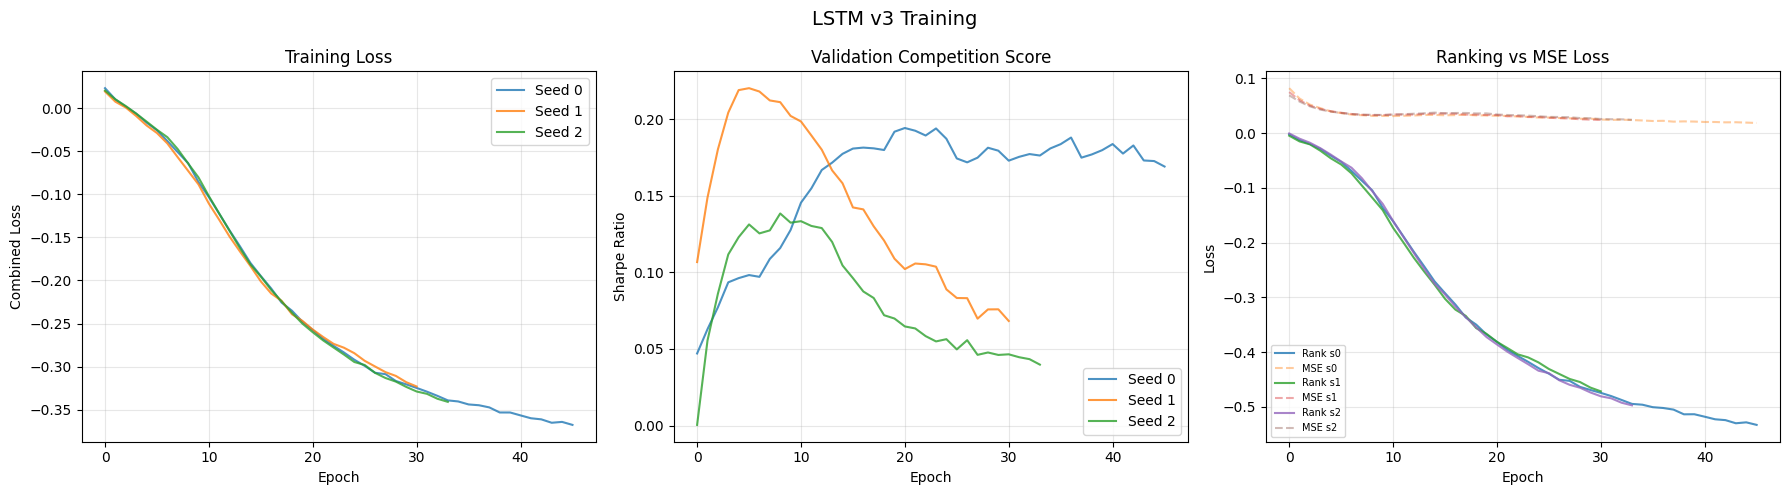

In [11]:
# %% ============================================================
# CELL 11: Plot Training
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
 
for s, hist in enumerate(histories):
    axes[0].plot(hist["train_loss"], label=f"Seed {s}", alpha=0.8)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Combined Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
for s, hist in enumerate(histories):
    axes[1].plot(hist["val_sharpe"], label=f"Seed {s}", alpha=0.8)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title("Validation Competition Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
 
for s, hist in enumerate(histories):
    axes[2].plot(hist["rank_loss"], label=f"Rank s{s}", alpha=0.8)
    axes[2].plot(hist["mse_loss"], label=f"MSE s{s}", alpha=0.4, linestyle="--")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].set_title("Ranking vs MSE Loss")
axes[2].legend(fontsize=7)
axes[2].grid(True, alpha=0.3)
 
plt.suptitle("LSTM v3 Training", fontsize=14)
plt.tight_layout()
plt.savefig("training_v3.png", dpi=150)
plt.show()

In [12]:
# %% ============================================================
# CELL 12: Generate Test Predictions (Ensemble)
# ===============================================================
print("Generating test predictions...")
 
all_preds = []
for s, model in enumerate(models):
    preds = predict_all(model, test_pca, SEQUENCE_LENGTH, DEVICE)
    all_preds.append(preds)
    print(f"  Seed {s}: {preds.shape}")
 
# Average across seeds
ensemble_preds = np.mean(all_preds, axis=0)
 
# Build DataFrame
valid_test_indices = list(range(SEQUENCE_LENGTH, len(test_pca)))
valid_date_ids = test.iloc[valid_test_indices]["date_id"].values
 
pred_df = pd.DataFrame(ensemble_preds, columns=target_cols)
pred_df.insert(0, "date_id", valid_date_ids)
 
print(f"Predictions: {pred_df.shape}")

Generating test predictions...
  Seed 0: (114, 424)
  Seed 1: (114, 424)
  Seed 2: (114, 424)
Predictions: (114, 425)


In [13]:
# Score seed 0 alone (the best val Sharpe model)
seed0_preds = all_preds[0]  # from Cell 12
seed0_df = pd.DataFrame(seed0_preds, columns=target_cols)
seed0_df.insert(0, "date_id", valid_date_ids)

seed0_gt = ground_truth[ground_truth["date_id"].isin(seed0_df["date_id"])].reset_index(drop=True)
seed0_aligned = seed0_df[seed0_df["date_id"].isin(seed0_gt["date_id"])].reset_index(drop=True)

print("Seed 0 alone:")
competition_score(seed0_aligned, seed0_gt, target_cols)

Seed 0 alone:
  Daily rank corr: mean=0.0779, std=0.2760, Sharpe=0.2822, days=114


(np.float64(0.282205718837038),
 array([ 0.01410418, -0.39261872, -0.40470595, -0.0040153 ,  0.27099671,
        -0.03859419,  0.20012783, -0.04785054, -0.17157406,  0.19358097,
         0.24344786,  0.4385019 , -0.19868216, -0.19089711, -0.11243189,
        -0.02845617,  0.27127479,  0.4424633 ,  0.63288025,  0.47418736,
         0.3969066 ,  0.48487377,  0.12590314, -0.04821415,  0.01850536,
        -0.02112483,  0.6630195 ,  0.65531663,  0.58177313,  0.20127455,
         0.06287923,  0.09276611, -0.06729182,  0.15882243,  0.33910423,
         0.14573878,  0.27634433, -0.58116954,  0.23031384,  0.54353933,
         0.39417276,  0.4734309 ,  0.14692421, -0.20961849, -0.61897525,
         0.62986074,  0.44118576, -0.21136044,  0.29799433,  0.05814381,
         0.03052796, -0.30631679,  0.30945309, -0.00615561, -0.45251945,
         0.2272348 ,  0.08848151, -0.2387116 ,  0.00123897,  0.11990003,
         0.13378358,  0.02909942, -0.30481728, -0.36137987, -0.30128636,
         0.04341527

In [14]:
# %% ============================================================
# CELL 13: Evaluate
# ===============================================================
gt_aligned = ground_truth[ground_truth["date_id"].isin(pred_df["date_id"])].reset_index(drop=True)
pred_aligned = pred_df[pred_df["date_id"].isin(gt_aligned["date_id"])].reset_index(drop=True)
 
print("=" * 55)
print("EVALUATION ON ALL TEST DATES:")
print("=" * 55)
sharpe_all, daily_all = competition_score(pred_aligned, gt_aligned, target_cols)
 
# Scored dates only
scored_dates = test.loc[is_scored, "date_id"].values
gt_scored = gt_aligned[gt_aligned["date_id"].isin(scored_dates)].reset_index(drop=True)
pred_scored = pred_aligned[pred_aligned["date_id"].isin(scored_dates)].reset_index(drop=True)
 
print("\nSCORED DATES ONLY:")
sharpe_scored, daily_scored = competition_score(pred_scored, gt_scored, target_cols)
 
# Per-lag Spearman (informational)
print("\nPer-target Spearman (informational):")
for lag in [1, 2, 3, 4]:
    lag_targets = lag_groups[lag]
    lag_corrs = []
    for col in lag_targets:
        mask = gt_aligned[col].notna()
        if mask.sum() < 5:
            continue
        c, _ = spearmanr(pred_aligned.loc[mask, col], gt_aligned.loc[mask, col])
        lag_corrs.append(c)
    print(f"  Lag {lag}: mean={np.nanmean(lag_corrs):.4f}, "
          f"positive={sum(1 for c in lag_corrs if c > 0)}/{len(lag_corrs)}")

EVALUATION ON ALL TEST DATES:
  Daily rank corr: mean=0.0606, std=0.1765, Sharpe=0.3433, days=114

SCORED DATES ONLY:
  Daily rank corr: mean=0.0568, std=0.1883, Sharpe=0.3016, days=70

Per-target Spearman (informational):
  Lag 1: mean=0.0342, positive=71/106
  Lag 2: mean=0.0684, positive=85/106
  Lag 3: mean=0.0686, positive=74/106
  Lag 4: mean=0.0854, positive=76/106


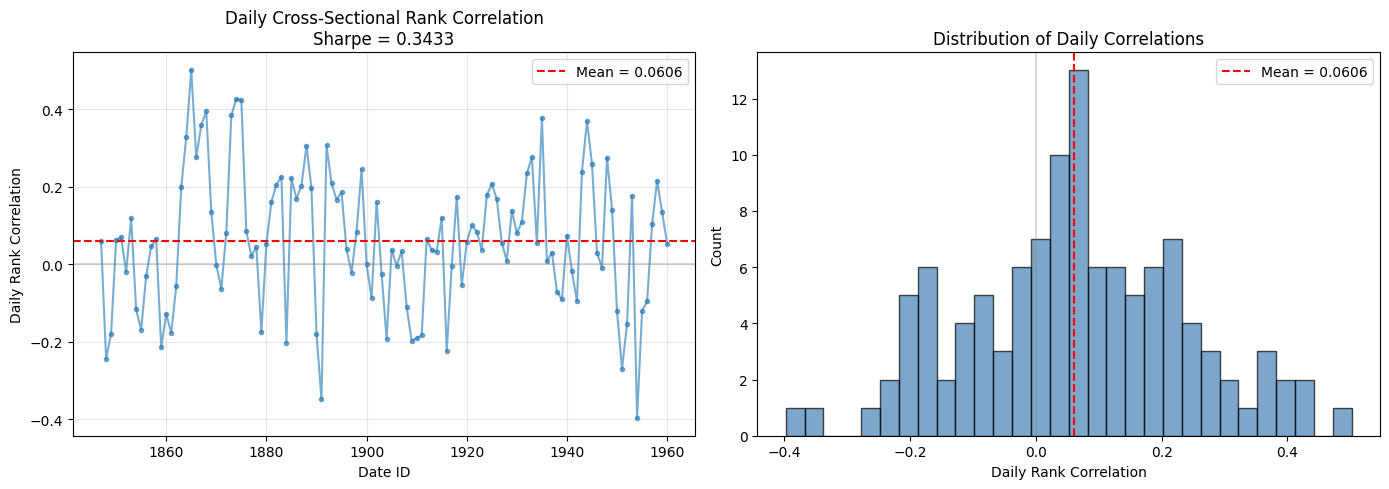

In [15]:
# %% ============================================================
# CELL 14: Visualize Daily Rank Correlations
# ===============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(valid_date_ids[:len(daily_all)], daily_all, marker=".", alpha=0.6)
axes[0].axhline(daily_all.mean(), color="red", linestyle="--",
                label=f"Mean = {daily_all.mean():.4f}")
axes[0].axhline(0, color="gray", linestyle="-", alpha=0.3)
axes[0].set_xlabel("Date ID")
axes[0].set_ylabel("Daily Rank Correlation")
axes[0].set_title(f"Daily Cross-Sectional Rank Correlation\nSharpe = {sharpe_all:.4f}")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
 
axes[1].hist(daily_all, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
axes[1].axvline(daily_all.mean(), color="red", linestyle="--",
                label=f"Mean = {daily_all.mean():.4f}")
axes[1].axvline(0, color="gray", linestyle="-", alpha=0.3)
axes[1].set_xlabel("Daily Rank Correlation")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Daily Correlations")
axes[1].legend()
 
plt.tight_layout()
plt.savefig("daily_correlations_v3.png", dpi=150)
plt.show()

In [16]:
# %% ============================================================
# CELL 15: Save Everything
# ===============================================================
pred_df.to_csv("predictions_lstm_v3.csv", index=False)
 
for s, model in enumerate(models):
    torch.save(model.state_dict(), f"model_v3_seed{s}.pt")
 
# Save config for reproducibility
config = {
    "SEQUENCE_LENGTH": SEQUENCE_LENGTH, "HIDDEN_SIZE": HIDDEN_SIZE,
    "NUM_LAYERS": NUM_LAYERS, "DROPOUT": DROPOUT,
    "LEARNING_RATE": LEARNING_RATE, "WEIGHT_DECAY": WEIGHT_DECAY,
    "N_PCA": N_PCA, "RANK_LOSS_ALPHA": RANK_LOSS_ALPHA,
    "TRAIN_END": TRAIN_END, "VAL_END": VAL_END,
    "sharpe_all": float(sharpe_all), "sharpe_scored": float(sharpe_scored),
}
pd.Series(config).to_json("config_v3.json")
 
print(f"\nSaved predictions, {N_SEEDS} models, and config")
print(f"\n{'='*55}")
print(f"  FINAL SCORE (all dates):   {sharpe_all:.4f}")
print(f"  FINAL SCORE (scored only): {sharpe_scored:.4f}")
print(f"{'='*55}")


Saved predictions, 3 models, and config

  FINAL SCORE (all dates):   0.3433
  FINAL SCORE (scored only): 0.3016
